## Automated Batch Kinetic Analysis

This script allows the automated analysis of single-wavelength kinetics, e.g., done on plate readers in absorbance mode.

**Part I:** Define the name of the input .xlsx file, and process the data

In [7]:
# File path of the Excel sheet with the raw data:
input_excel = 'SK121_example.xlsx'

In [8]:
import pandas as pd

def read_excel(input_excel):
    # Read the initial rows to find the correct starting point
    df = pd.read_excel(input_excel, nrows=20)
    
    # Find the row index where the "Reading" header is located
    reading_row_index = df[df.iloc[:, 0] == 'Reading'].index[0]
    
    # Read the Excel file again, skipping rows up to the "Reading" header
    df = pd.read_excel(input_excel, skiprows=reading_row_index + 1)
    
    # Remove the 'Unnamed' columns if they exist
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    return df

# Read Excel file into DataFrame
data_frame = read_excel(input_excel)

# Remove the "Reading" column
data_frame = data_frame.drop(columns=['Reading'])

# Rename the column 'avg. time [s]' to 'Time'
data_frame = data_frame.rename(columns={"avg. time [s]": "Time"})

data_frame

,Time,A01,B01,C01
0,0.00,1.4879,1.8225,1.6682
1,4.99,1.4997,1.8189,1.6791
2,9.99,1.4967,1.8256,1.6812
3,14.99,1.4964,1.8152,1.6846
4,19.99,1.4949,1.8122,1.6871
...,...,...,...,...
2179,67369.99,1.0876,0.8396,1.1877
2180,67549.99,1.0876,0.8396,1.1871
2181,67729.99,1.0880,0.8397,1.1873
2182,67909.99,1.0877,0.8394,1.1872


**Part II:** Kinetic fitting

This analysis assumes that the kinetics follow a first-order decay, e.g., are recorded under pseudo-first-order conditions.

To ensure reproducible fitting of the monoexponential decay of measurement series where the kinetics cover the whole time range or just a small part of it (e.g., just the beginning), the data is analyzed in a multistep process. 

Initially, exponential fits are generated on different time regions by multiplying the total length of the dataset by a factor that is in the current settings 0.5. This will generate subsets of the data with a length of, e.g., 100%, 50%, 25%, 12.5% of the original dataset. For each of these regions, a "crude" fit is taken, which best describes the data. Here, the longest fit that still yields decent quality is selected (this is defined using the value __r2_tolerance=0.0050__ in R2; i.e., if the best fit only covers 2% of the data and has an R2 of 0.9999, then the longest fit that has an R2 of at least 0.9950 is selected). 

Subsequently, the fitting routine calculates the time at which this exponential function takes a specific conversion value, e.g., 90% (__conversion = 0.90__), and uses this as the end time for the fitting. Subsequently, the start time is dynamically adjusted to maximize the fitting quality. Here, the variable __max_start_time_adjustment__ tells how much can be at maximum be cut away (here, typically only a small amount is used, e.g., 10 s).

After the analysis is done, a .png for each analysis is saved, which contains graphs showing the experimental data, including the fit and residual, and a .txt output file with all fit parameters called fit_results.txt. 


__Troubleshooting__

x Adjustment of the r2_tolerance parameters may be necessary for "noisy" measurements, or for measurements where the analysis only fits a small part at the beginning. 

x Depending on the data, adjusting __maxfev_value__ may be needed, which increases the number of iterations. 

x Depending on the data, the multiplicative factor may need to be adjusted from 0.5 to a larger number. This will result in more intervals that are evaluated.

x The analysis will only work well for kinetics that follow a first-order decay. More complex kinetic curves cannot be reliably analyzed with this method.

[0.00781, 0.01562, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1.0]
Time for a conversion of 0.9: 5645.67
Time for a conversion of 0.9: 5645.67 (closest time point in dataset: 5659.99)
Region 0.781% for A01: R2 = 0.6259
Region 1.562% for A01: R2 = 0.7497
Region 3.125% for A01: R2 = 0.2859
Region 6.25% for A01: R2 = 0.9022
Region 12.5% for A01: R2 = 0.9871
Region 25.0% for A01: R2 = 0.9973
Region 50.0% for A01: R2 = 0.9973
Region 100.0% for A01: R2 = 0.9963
Chosen region for A01: 100.0% provided R2 = 0.9963
Chosen fit start time: 0.0, end time: 68089.99
A01 - Precise Fit Start Time: 164.99, End Time: 5659.99


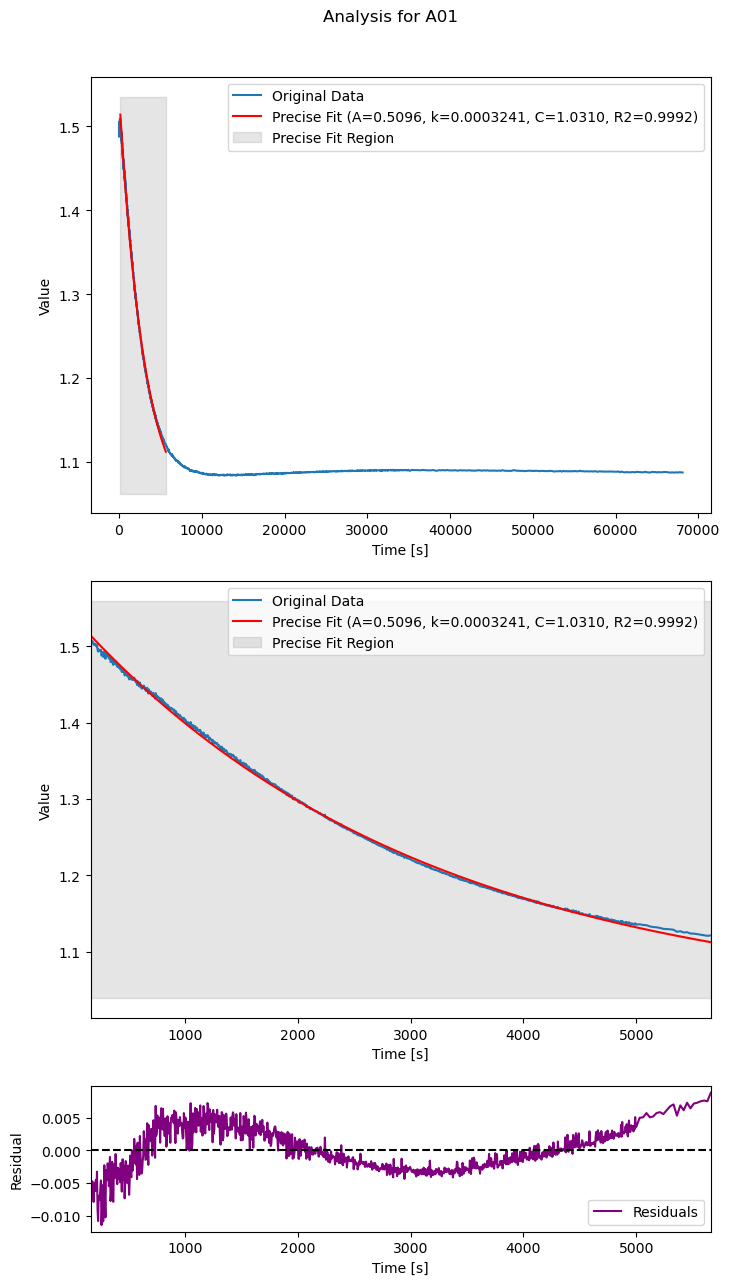

[0.00781, 0.01562, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1.0]
Time for a conversion of 0.9: 13815.66
Time for a conversion of 0.9: 13815.66 (closest time point in dataset: 13819.99)
Region 0.781% for B01: R2 = 0.1783
Region 1.562% for B01: R2 = 0.1186
Region 3.125% for B01: R2 = 0.5949
Region 6.25% for B01: R2 = 0.9145
Region 12.5% for B01: R2 = 0.9616
Region 25.0% for B01: R2 = 0.9927
Region 50.0% for B01: R2 = 0.9968
Region 100.0% for B01: R2 = 0.9976
Chosen region for B01: 100.0% provided R2 = 0.9976
Chosen fit start time: 0.0, end time: 68089.99
B01 - Precise Fit Start Time: 409.99, End Time: 13819.99


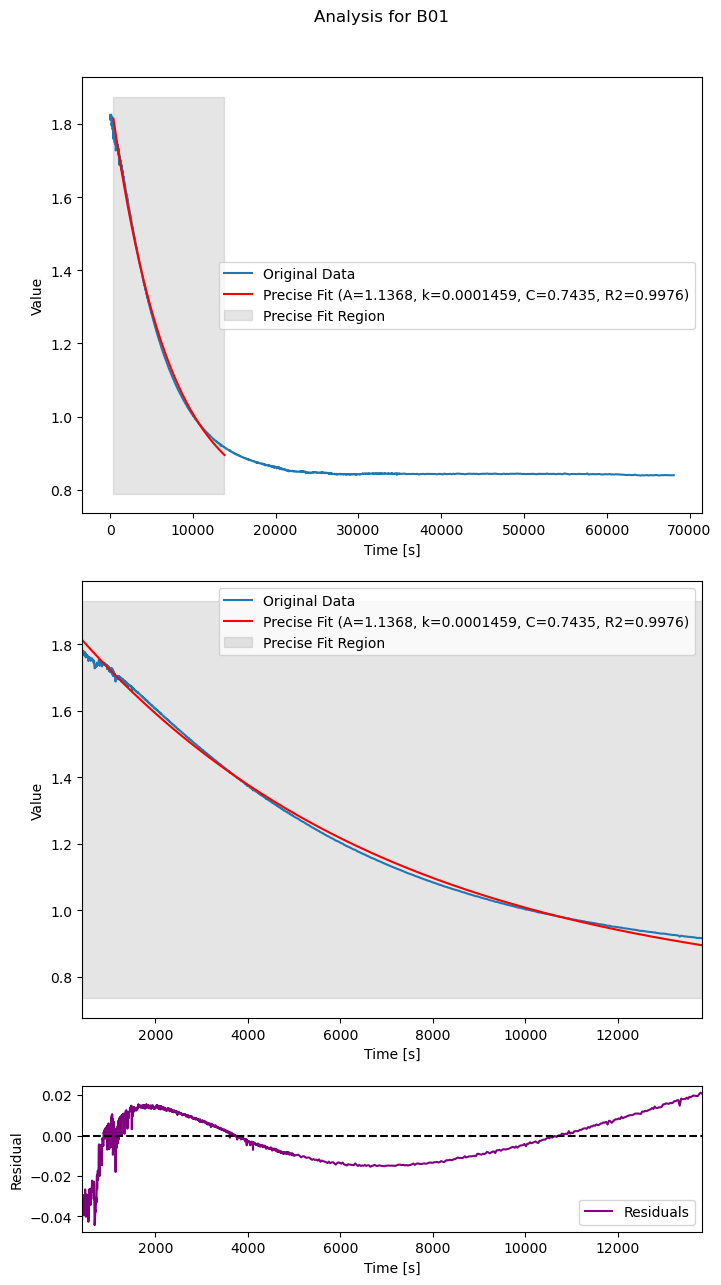

[0.00781, 0.01562, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1.0]
Time for a conversion of 0.9: 54860.89
Time for a conversion of 0.9: 54860.89 (closest time point in dataset: 54949.99)
Region 0.781% for C01: R2 = 0.8030
Region 1.562% for C01: R2 = 0.6769
Region 3.125% for C01: R2 = 0.4177
Region 6.25% for C01: R2 = 0.0001
Region 12.5% for C01: R2 = 0.5491
Region 25.0% for C01: R2 = 0.9354
Region 50.0% for C01: R2 = 0.9915
Region 100.0% for C01: R2 = 0.9995
Chosen region for C01: 100.0% provided R2 = 0.9995
Chosen fit start time: 0.0, end time: 68089.99
C01 - Precise Fit Start Time: 1644.99, End Time: 54949.99


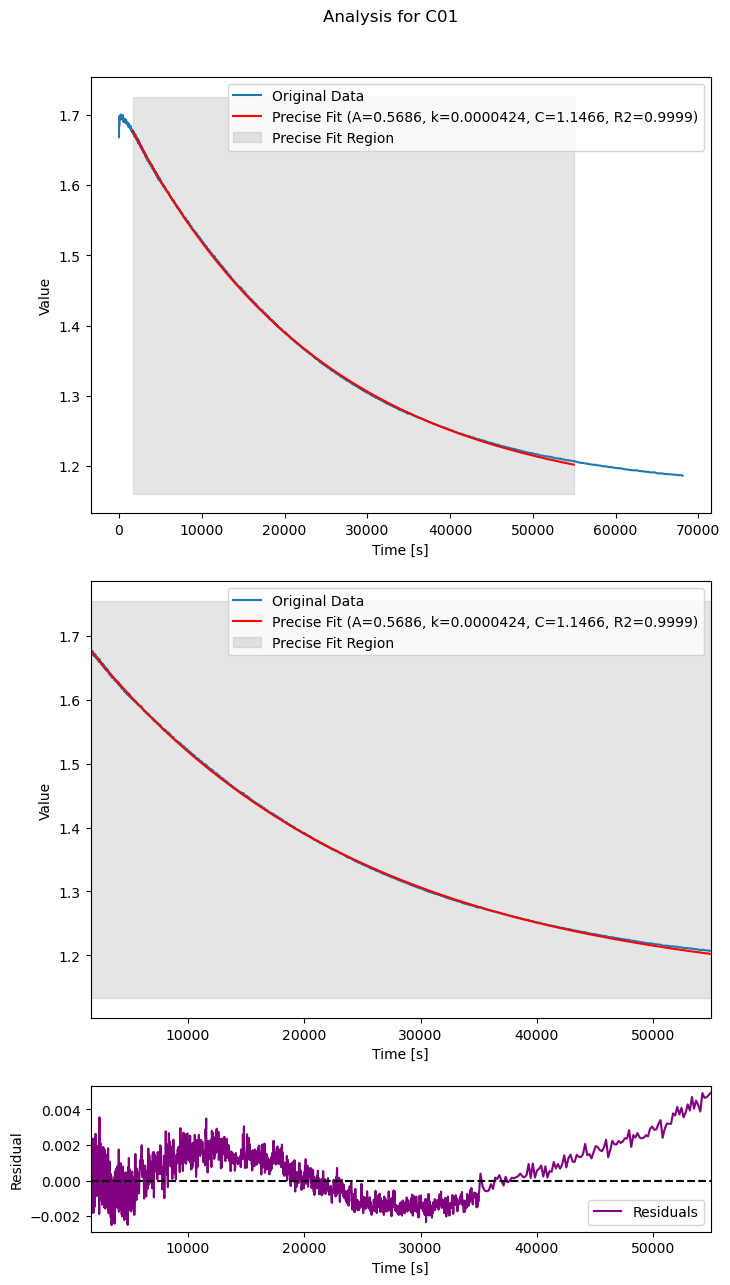

Fit Results:
A01: A = 5.096e-01, k = 3.241e-04, C = 1.031e+00, R2 = 9.992e-01, Chosen Region = 1.0, Chosen Fit Start Time = 0.0, Chosen Fit End Time = 68089.99, Precise Fit Start Time = 165.0, Precise Fit End Time = 5660.0
B01: A = 1.137e+00, k = 1.459e-04, C = 7.435e-01, R2 = 9.976e-01, Chosen Region = 1.0, Chosen Fit Start Time = 0.0, Chosen Fit End Time = 68089.99, Precise Fit Start Time = 410.0, Precise Fit End Time = 13820.0
C01: A = 5.686e-01, k = 4.235e-05, C = 1.147e+00, R2 = 9.999e-01, Chosen Region = 1.0, Chosen Fit Start Time = 0.0, Chosen Fit End Time = 68089.99, Precise Fit Start Time = 1645.0, Precise Fit End Time = 54950.0
Fit results saved to fit_results.txt


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Function for the exponential decay model with offset
def exponential_decay_with_offset(x, A, k, C):
    return A * np.exp(-k * x) + C

# Non-linear fitting and analysis
fit_results = {}  # Dictionary to store fit parameters
maxfev_value = 200000  # Increase the max function evaluation limit
r2_tolerance = 0.0050  # Tolerance for R2 value difference to consider a region
max_start_time_adjustment_factor = 0.03 # Conversion that can be cut away at the start  
conversion = 0.90

def calculate_time_regions(data_length, min_points=10):
    time_regions = []
    region = 1.0
    while True:
        final_index = int(region * data_length)
        if final_index < min_points:
            break
        time_regions.append(round(region, 5))  # Round to at most 5 decimals
        region *= 0.5 # This is the multiplicative factor used to generate the time regions.
    return sorted(time_regions)  # Return the time regions in ascending order

for column in data_frame.columns[1:]:  # Exclude the 'Time' column
    x = data_frame['Time'].values
    y = data_frame[column].values
    
    time_regions = calculate_time_regions(len(x))
    print(time_regions)
    best_region_length = 0
    best_params = None
    best_region = None
    best_r2 = -float('inf')  # Initialize best_r2 to negative infinity

    for region in time_regions:
        try:
            final_index = int(region * len(x))
            x_fit = x[:final_index]
            y_fit = y[:final_index]
            

            if len(y_fit) < 3:
                continue

            initial_guesses = [y_fit[0], 0.00001, 0.0]

            params, covariance = curve_fit(exponential_decay_with_offset, x_fit, y_fit, p0=initial_guesses, maxfev=maxfev_value)
            y_pred = exponential_decay_with_offset(x_fit, *params)
            r2 = r2_score(y_fit, y_pred)

            if final_index > best_region_length and r2 >= best_r2 - r2_tolerance:
                best_region_length = final_index
                best_params = params
                best_r2 = r2
                best_region = region

        except Exception as e:
            print(f"Fit for {column} in region {region*100}% failed: {e}")

    if best_region is not None:
        custom_region_index = best_region_length
        x_custom_fit = x[:custom_region_index]
        y_custom_fit = y[:custom_region_index]
        params_custom, _ = curve_fit(exponential_decay_with_offset, x_custom_fit, y_custom_fit, p0=best_params, maxfev=maxfev_value)
        y_custom_fit_pred = exponential_decay_with_offset(x_custom_fit, *params_custom)

        # Calculate t_conv based on the provided formulas
        A, k, C = params_custom
        k_value = k
        t_conv = np.log(1 / (1 - conversion)) / k_value
        
        # If t_conv is negative, skip the precise fit steps and record NN entries
        if t_conv < 0:
            fit_results[column] = {
                'A': np.nan,
                'k': np.nan,
                'C': np.nan,
                'R2': np.nan,
                'chosen_region': np.nan,
                'chosen_fit_start_time': np.nan,
                'chosen_fit_end_time': np.nan,
                'precise_fit_start_time': np.nan,
                'precise_fit_end_time': np.nan
            }
            print(f"Skipping precise fit for {column} due to negative t_conv")
            continue

        print(f"Time for a conversion of {conversion}: {t_conv:.2f}")

        # Find the closest time point to t_conv in the dataset
        closest_time_point = x[np.abs(x - t_conv).argmin()]
        print(f"Time for a conversion of {conversion}: {t_conv:.2f} (closest time point in dataset: {closest_time_point})")

        # Set precise fit end time to the closest time point
        precise_fit_end_time = closest_time_point
        
        # Define precise fit start time
        
        max_start_time_adjustment = max_start_time_adjustment_factor * precise_fit_end_time
        
        
        precise_fit_start_index = max(np.where(x_custom_fit <= min(x_custom_fit[-1], x[0] + max_start_time_adjustment))[0][-1], 0)
        precise_fit_start_time = x[precise_fit_start_index]
        
        # Update x_custom_fit and y_custom_fit with dynamic precise fit time range
        precise_fit_indices = np.where((x_custom_fit >= precise_fit_start_time) & (x_custom_fit <= precise_fit_end_time))[0]
        precise_x_custom_fit = x_custom_fit[precise_fit_indices]
        precise_y_custom_fit = y_custom_fit[precise_fit_indices]

        # Perform the curve fitting again within the precise time range
         
        min_points_needed = 3  
        if len(precise_x_custom_fit) >= min_points_needed and len(precise_y_custom_fit) >= min_points_needed:
            
            params_precise, _ = curve_fit(exponential_decay_with_offset, precise_x_custom_fit, precise_y_custom_fit, p0=params_custom, maxfev=maxfev_value)
            y_precise_fit_pred = exponential_decay_with_offset(precise_x_custom_fit, *params_precise)
            precise_r2 = r2_score(precise_y_custom_fit, y_precise_fit_pred)
        else:
            print(f"Skipping precise fit for {column} due to insufficient data points ({len(precise_x_custom_fit)} found, {min_points_needed} required).")
            params_precise = params_custom
            y_precise_fit_pred = y_custom_fit_pred
            precise_r2 = best_r2

        # Ensure both arrays are one-dimensional
        precise_x_custom_fit = np.atleast_1d(precise_x_custom_fit)
        y_precise_fit_pred = np.atleast_1d(y_precise_fit_pred)
        # Store the best fit parameters, precise fit times, and region
        A, k, C = params_precise
        fit_results[column] = {
            'A': A, 
            'k': k, 
            'C': C, 
            'R2': precise_r2,
            'chosen_region': best_region,
            'chosen_fit_start_time': x[0],
            'chosen_fit_end_time': x[custom_region_index - 1],
            'precise_fit_start_time': precise_fit_start_time,
            'precise_fit_end_time': precise_fit_end_time
        }

        # Print information on evaluated regions
        for region in time_regions:
            x_fit_region = x[:int(region * len(x))]
            y_fit_region = y[:int(region * len(y))]
            params_region, _ = curve_fit(exponential_decay_with_offset, x_fit_region, y_fit_region, p0=initial_guesses, maxfev=maxfev_value)
            y_pred_region = exponential_decay_with_offset(x_fit_region, *params_region)
            r2_region = r2_score(y_fit_region, y_pred_region)
            print(f"Region {region*100}% for {column}: R2 = {r2_region:.4f}")

        print(f"Chosen region for {column}: {best_region*100}% provided R2 = {best_r2:.4f}")
        print(f"Chosen fit start time: {x[0]}, end time: {x[custom_region_index - 1]}")
        print(f"{column} - Precise Fit Start Time: {precise_fit_start_time}, End Time: {precise_fit_end_time}")
       
        # Plot the coarse fit and the residuals for the precise fit
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 15), gridspec_kw={'height_ratios': [3, 3, 1]})
        fig.suptitle(f'Analysis for {column}', y=0.925)

        # Plot the original data, coarse fit, and precise fit on the first subplot

        ax1.plot(x, y, label='Original Data')

        if len(precise_x_custom_fit) == len(y_precise_fit_pred):
            ax1.plot(precise_x_custom_fit, y_precise_fit_pred, label=f'Precise Fit (A={params_precise[0]:.4f}, k={params_precise[1]:.7f}, C={params_precise[2]:.4f}, R2={precise_r2:.4f})', color='red')
        else:
            print(f"Skipping plot for {column} due to mismatched dimensions: precise_x_custom_fit has {len(precise_x_custom_fit)} points, y_precise_fit_pred has {len(y_precise_fit_pred)} points.")
        ax1.fill_betweenx(ax1.get_ylim(), precise_fit_start_time, precise_fit_end_time, color='gray', alpha=0.2, label='Precise Fit Region')
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('Value')
        ax1.legend()
        
        # Plot the original data, coarse fit, and precise fit on the second subplot
        ax2.plot(x, y, label='Original Data')
        if len(precise_x_custom_fit) == len(y_precise_fit_pred):
           ax2.plot(precise_x_custom_fit, y_precise_fit_pred, label=f'Precise Fit (A={A:.4f}, k={k:.7f}, C={C:.4f}, R2={precise_r2:.4f})', color='red')
        else:
           print(f"Skipping plot for {column} due to mismatched dimensions: precise_x_custom_fit has {len(precise_x_custom_fit)} points, y_precise_fit_pred has {len(y_precise_fit_pred)} points.")
        
        ax2.fill_betweenx(ax1.get_ylim(), precise_fit_start_time, precise_fit_end_time, color='gray', alpha=0.2, label='Precise Fit Region')
        ax2.set_xlabel('Time [s]')
        ax2.set_ylabel('Value')
        ax2.set_xlim(precise_fit_start_time, precise_fit_end_time)
        ax2.legend()
        
        # Plot the residuals for the precise fit on the third subplot
        
        if len(precise_x_custom_fit) == len(y_precise_fit_pred):
            residuals = precise_y_custom_fit - y_precise_fit_pred
            ax3.plot(precise_x_custom_fit, residuals, label='Residuals', color='purple')
        else:
            print(f"Skipping plot for {column} due to mismatched dimensions: precise_x_custom_fit has {len(precise_x_custom_fit)} points, y_precise_fit_pred has {len(y_precise_fit_pred)} points.")
        
        ax3.axhline(y=0, color='black', linestyle='--')
        ax3.set_xlabel('Time [s]')
        ax3.set_ylabel('Residual')
        ax3.set_xlim(precise_fit_start_time, precise_fit_end_time)  # Adjust x-axis range to match precise fit time
        ax3.legend()
        
        # Save the plot as a PNG file
        output_file_path = f'{column}_fit_results.png'
        plt.savefig(output_file_path)
        
        plt.show()

    else:
        # Record NN entries if no best region was found
        fit_results[column] = {
            'A': 'NN',
            'k': 'NN',
            'C': 'NN',
            'R2': 'NN',
            'chosen_region': 'NN',
            'chosen_fit_start_time': 'NN',
            'chosen_fit_end_time': 'NN',
            'precise_fit_start_time': 'NN',
            'precise_fit_end_time': 'NN'
        }

# Display fit results
print("Fit Results:")
for column, params in fit_results.items():
    A = 'NN' if np.isnan(params.get('A')) else f"{params.get('A'):.3e}"
    k = 'NN' if np.isnan(params.get('k')) else f"{params.get('k'):.3e}"
    C = 'NN' if np.isnan(params.get('C')) else f"{params.get('C'):.3e}"
    R2 = 'NN' if np.isnan(params.get('R2')) else f"{params.get('R2'):.3e}"
    precise_fit_start_time = 'NN' if np.isnan(params.get('precise_fit_start_time')) else f"{params.get('precise_fit_start_time'):.1f}"
    precise_fit_end_time = 'NN' if np.isnan(params.get('precise_fit_end_time')) else f"{params.get('precise_fit_end_time'):.1f}"
    print(f"{column}: A = {A}, k = {k}, C = {C}, R2 = {R2}, "
          f"Chosen Region = {params.get('chosen_region', 'NN')}, "
          f"Chosen Fit Start Time = {params.get('chosen_fit_start_time', 'NN')}, "
          f"Chosen Fit End Time = {params.get('chosen_fit_end_time', 'NN')}, "
          f"Precise Fit Start Time = {precise_fit_start_time}, "
          f"Precise Fit End Time = {precise_fit_end_time}")

# Save fit results to a text file
output_file_path = 'fit_results.txt'
with open(output_file_path, 'w') as output_file:
    output_file.write("Entry, A, k, C, R2, Fit_Start_Time, Fit_End_Time\n")
    for column, params in fit_results.items():
        A = 'NN' if np.isnan(params.get('A')) else f"{params.get('A'):.3e}"
        k = 'NN' if np.isnan(params.get('k')) else f"{params.get('k'):.3e}"
        C = 'NN' if np.isnan(params.get('C')) else f"{params.get('C'):.3e}"
        R2 = 'NN' if np.isnan(params.get('R2')) else f"{params.get('R2'):.3e}"
        precise_fit_start_time = 'NN' if np.isnan(params.get('precise_fit_start_time')) else f"{params.get('precise_fit_start_time'):.1f}"
        precise_fit_end_time = 'NN' if np.isnan(params.get('precise_fit_end_time')) else f"{params.get('precise_fit_end_time'):.1f}"
        output_file.write(f"{column}, {A}, {k}, {C}, {R2}, {precise_fit_start_time}, {precise_fit_end_time}\n")

print(f"Fit results saved to {output_file_path}")